In [1]:
from IPython.display import Image
import xarray as xr
import numpy as np
import pandas as pd
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import to_hex
from shapely.geometry import Polygon
from matplotlib.path import Path
import pandas as pd
import matplotlib.gridspec as gridspec
import glob
import time
import gc

In [2]:
import xarray as xr
import numpy as np
import threading

# ── PAS de LocalCluster — scheduler synchrone pour la lecture ────────────────
# On n'utilise Dask distribué QUE si nécessaire pour les calculs lourds

# Lock global HDF5 : force l'accès séquentiel aux fichiers
HDF5_LOCK = threading.Lock()

# ── Helper preprocess ────────────────────────────────────────────────────────
def preprocess_pr(ds):
    ds = ds.sel(latitude=slice(-10, -44), longitude=slice(112, 154))
    if 'expver' in ds.dims:
        ds = ds.sel(expver=1, drop=True).combine_first(ds.sel(expver=5, drop=True))
    return ds[['tp']]

def preprocess_mslp(ds):
    return ds[['msl']].sel(latitude=[-40, -65], method='nearest')

# ── 1. PR (ERA5) ──────────────────────────────────────────────────────────────
import glob, os
files_pr = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/tp/**/*.nc',
                             recursive=True))
print(f"{len(files_pr)} fichiers PR trouvés")

ds_pr = xr.open_mfdataset(
    files_pr,
    parallel=False,
    preprocess=preprocess_pr,
    combine='by_coords',
    engine='netcdf4',
    chunks={'time': 12},
    # Pas de Dask distribué : scheduler='synchronous' forcé au compute
)
pr_mm_day = ds_pr.tp * 1000
pr = pr_mm_day * pr_mm_day.time.dt.days_in_month
pr.attrs['units'] = 'mm/month'
print("PR ouvert ✓")

# ── 2. MSLP / SAM — lecture fichier par fichier avec boucle explicite ─────────
# C'est plus lent mais 100% fiable sur Lustre
files_mslp = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/msl/**/*.nc',
                               recursive=True))
print(f"{len(files_mslp)} fichiers MSLP trouvés")

p40_list, p65_list, times = [], [], []

for f in files_mslp:
    try:
        with xr.open_dataset(f, engine='netcdf4') as ds:
            msl = ds['msl']
            if 'expver' in msl.dims:
                msl = msl.sel(expver=1, drop=True).combine_first(
                      msl.sel(expver=5, drop=True))
            lat40 = msl.sel(latitude=-40, method='nearest').mean(dim='longitude')
            lat65 = msl.sel(latitude=-65, method='nearest').mean(dim='longitude')
            # .values force la lecture immédiate AVANT fermeture du fichier
            p40_list.append(float(lat40.values))
            p65_list.append(float(lat65.values))
            times.append(ds.time.values[0])
    except OSError as e:
        print(f"  ⚠ Fichier corrompu ignoré : {os.path.basename(f)} — {e}")
        continue

# Reconstruction propre en Series pandas
import pandas as pd
idx = pd.DatetimeIndex(times)
p40 = pd.Series(p40_list, index=idx).sort_index()
p65 = pd.Series(p65_list, index=idx).sort_index()
sam  = p40 - p65
print(f"SAM calculé ✓ ({len(sam)} mois)")

# --- CONFIGURATION SM ---
root_awra = '/g/data/iu04/australian-water-outlook/historical/v1/AWRALv7/'
LON_SLICE = slice(112, 154)
LAT_SLICE_AUM = slice(-10, -44)
years_needed = range(1940, 2024)

sm_yearly_list = []

print("Début du chargement itératif de la Soil Moisture (0-6m)...")

for yr in years_needed:
    f0 = f"{root_awra}s0_{yr}.nc"
    fs = f"{root_awra}ss_{yr}.nc"
    fd = f"{root_awra}sd_{yr}.nc"
    
    # Vérification de l'existence des fichiers pour éviter de bloquer
    if not all(os.path.exists(f) for f in [f0, fs, fd]):
        continue
        
    try:
        # Ouverture individuelle (plus léger que mfdataset ici)
        with xr.open_dataset(f0) as ds0, xr.open_dataset(fs) as dss, xr.open_dataset(fd) as dsd:
            # Sélection et conversion float32 immédiate
            s0 = ds0.s0.sel(longitude=LON_SLICE, latitude=LAT_SLICE_AUM).astype('float32')
            ss = dss.ss.sel(longitude=LON_SLICE, latitude=LAT_SLICE_AUM).astype('float32')
            sd = dsd.sd.sel(longitude=LON_SLICE, latitude=LAT_SLICE_AUM).astype('float32')
            
            # Somme des 3 couches
            sm_total = s0*0.1 + ss*0.9 + sd*5
            
            # Moyenne mensuelle immédiate (compute force le calcul et libère les fichiers)
            sm_monthly = sm_total.resample(time='1MS').mean().compute()
            sm_yearly_list.append(sm_monthly)
            
    except Exception as e:
        print(f"  ⚠️ Erreur pour l'année {yr}: {e}")
        continue

    if yr % 10 == 0:
        print(f"  ✓ Année {yr} traitée.")
        gc.collect()

# Assemblage final
if sm_yearly_list:
    sm = xr.concat(sm_yearly_list, dim='time').sortby('time')
    sm = sm.rename('sm')
    del sm_yearly_list
    gc.collect()
    print(f"✅ Soil Moisture 0-6m prête. ({sm.time.size} mois)")
else:
    print("❌ Erreur : sm_yearly_list est vide.")

# ── 4. SST ────────────────────────────────────────────────────────────────────
sst_ds = xr.open_dataset(
    '/g/data/m35/qr1706/PhD-1_CMIP_analysis/data uploaded/ersstv5.nc',
    chunks={'time': 24}
)
sst = sst_ds.sst.sel(time=slice("1940-01-01", "2023-08-01"))

# ── Pour les calculs lourds sur pr/sm : forcer scheduler synchrone ─────────── 
# Remplace .compute() par .compute(scheduler='synchronous')
# Exemple :
# pr_mean = pr.mean(dim='time').compute(scheduler='synchronous')

804 fichiers PR trouvés
PR ouvert ✓
804 fichiers MSLP trouvés
SAM calculé ✓ (804 mois)
Début du chargement itératif de la Soil Moisture (0-6m)...
  ✓ Année 1940 traitée.
  ✓ Année 1950 traitée.
  ✓ Année 1960 traitée.
  ✓ Année 1970 traitée.
  ✓ Année 1980 traitée.
  ✓ Année 1990 traitée.
  ✓ Année 2000 traitée.
  ✓ Année 2010 traitée.
  ✓ Année 2020 traitée.
✅ Soil Moisture 0-6m prête. (1008 mois)


In [3]:
# ==========================================
# CELLULE 2 — MASQUE + MOYENNE SPATIALE PR
# (réutilise pr, sm, sst, sam de la cellule 1)
# ==========================================
import dask
dask.config.set(scheduler='synchronous')  # ← évite le HDF error au .compute()

lat_b = (-23, -11)
lon_b = (122, 149)

# ── 1. Masque spatial (sur la grille SM déjà chargée) ────────────────────────
print("1. Création du masque spatial...")

def create_land_mask(da):
    lons, lats = np.meshgrid(da.longitude.values, da.latitude.values)
    points = np.column_stack((lons.flatten(), lats.flatten()))
    coastline_geom = cfeature.COASTLINE.geometries()
    mask = np.zeros(da.shape[1:], dtype=bool)
    bbox = Polygon([(112, -44), (154, -44), (154, -10), (112, -10)])
    for geom in coastline_geom:
        if bbox.intersects(geom):
            path = Path(np.array(geom.xy).T)
            mask |= path.contains_points(points).reshape(mask.shape)
    return xr.DataArray(mask, coords=[da.latitude, da.longitude], dims=['latitude', 'longitude'])

# sm est déjà chargé en cellule 1 — on le charge juste en mémoire si pas encore fait
sm_loaded = sm.load() if sm.chunks else sm

land_mask  = create_land_mask(sm_loaded)
na_mask    = (sm_loaded.latitude >= lat_b[0]) & (sm_loaded.latitude <= lat_b[1]) & \
             (sm_loaded.longitude >= lon_b[0]) & (sm_loaded.longitude <= lon_b[1])
final_mask = land_mask & na_mask
print("   Masque prêt ✓")

# ── 2. Moyenne spatiale PR (réutilise pr de cellule 1) ───────────────────────
print("2. Calcul moyenne spatiale PR...")
t_pr = time.time()

# pr est sur la grille ERA5 (~0.25°), sm sur grille AWRA (~0.05°)
# On aligne PR sur la grille SM avant d'appliquer le masque
pr_aligned  = pr.interp_like(sm_loaded.isel(time=0), method='nearest')
pr_ts_lazy  = pr_aligned.where(final_mask).mean(dim=['latitude', 'longitude'])
pr_ts_raw   = pr_ts_lazy.compute(scheduler='synchronous')  # ← séquentiel, pas de HDF error

# Correction décalage temporel ERA5 (milieu du mois)
pr_ts_raw['time'] = pr_ts_raw.time + np.timedelta64(14, 'D')
print(f"   PR moyenne prête en {time.time()-t_pr:.1f}s ✓")

# ── 3. Moyenne spatiale SM (réutilise sm de cellule 1) ───────────────────────
print("3. Calcul moyenne spatiale SM...")
sm_ts_raw = sm_loaded.where(final_mask).mean(dim=['latitude', 'longitude'])
print("   SM moyenne prête ✓")

# ── 4. SAM déjà calculé en cellule 1 — conversion en xr.DataArray ────────────
sam_ts_raw = xr.DataArray.from_series(sam)  # sam = pd.Series de cellule 1
print(f"   SAM disponible ✓ ({len(sam)} mois)")

# ── 5. SST déjà chargée en cellule 1 ─────────────────────────────────────────
# sst est prêt, rien à faire
print("   SST disponible ✓")
print("\n--- Prêt pour le detrending ---")

1. Création du masque spatial...
   Masque prêt ✓
2. Calcul moyenne spatiale PR...
   PR moyenne prête en 14.4s ✓
3. Calcul moyenne spatiale SM...
   SM moyenne prête ✓
   SAM disponible ✓ (804 mois)
   SST disponible ✓

--- Prêt pour le detrending ---


In [4]:
print("Date SM index 0:", sm_ts_raw.time.values[0])
print("Date PR index 0:", pr_ts_raw.time.values[0])
print("Date SST index 0:", sst.time.values[0])

Date SM index 0: 1940-01-01T00:00:00.000000000
Date PR index 0: 1959-01-15T00:00:00.000000000
Date SST index 0: 1940-01-01T00:00:00.000000000


In [5]:
# ==========================================
# 2. MOYENNES SPATIALES ET NETTOYAGE
# ==========================================
# Le masque a déjà été créé et utilisé pour ERA5 dans la cellule précédente.
# On s'assure juste que la moyenne de SM est bien calculée.

print("Calcul de la moyenne spatiale pour Soil Moisture...")
# sm est déjà chargé en mémoire (.load()), donc ce calcul est instantané
sm_ts_raw = sm.where(final_mask).mean(dim=['latitude', 'longitude'])

# Note : pr_ts_raw a été calculé lors de l'étape 5 de la cellule précédente 
# par la commande : pr_ts_raw = pr_ts_lazy.compute()
# On vérifie simplement qu'il existe
if 'pr_ts_raw' in locals():
    print("Moyenne spatiale PR (ERA5) déjà disponible.")
else:
    print("Erreur : pr_ts_raw n'a pas été trouvé. Vérifiez la cellule précédente.")

print("Moyennes spatiales prêtes.")

Calcul de la moyenne spatiale pour Soil Moisture...
Moyenne spatiale PR (ERA5) déjà disponible.
Moyennes spatiales prêtes.


In [6]:
# ==========================================
# 3. FONCTION DE DETRENDING
# ==========================================
def apply_detrend(da_ts):
    # Calcul de la moyenne mobile sur 240 mois (20 ans)
    moyenne_mobile = da_ts.rolling(time=240, center=True).mean()
    
    # Detrending
    da_detrended = da_ts - moyenne_mobile
    
    # Gestion des bords (10 ans début/fin)
    head_mean = da_ts.isel(time=slice(0, 120)).mean()
    da_detrended.values[:120] = da_ts.values[:120] - head_mean.values
    
    tail_start = len(da_ts) - 120
    tail_mean = da_ts.isel(time=slice(tail_start, None)).mean()
    da_detrended.values[tail_start:] = da_ts.values[tail_start:] - tail_mean.values
    
    return da_detrended.interpolate_na(dim="time", method="linear")

# Application sur tes nouvelles séries temporelles
print("Application du detrending...")
sm_ts = apply_detrend(sm_ts_raw)
pr_ts = apply_detrend(pr_ts_raw)

print("Detrending terminé.")


Application du detrending...
Detrending terminé.


In [7]:
# ==========================================
# 4. CALCUL DES INDICES CLIMATIQUES (ONI & IOD) - VERSION SYNCHRONISÉE
# ==========================================

def calculate_oni(sst_da):
    """Calcule l'indice ONI selon la méthodologie NOAA."""
    n34 = sst_da.sel(lat=slice(5, -5), lon=slice(190, 240))
    weights = np.cos(np.deg2rad(n34.lat))
    w_mean = n34.weighted(weights).mean(dim=['lat', 'lon'])
    
    anomalies = []
    for year in range(1950, 2011, 5):
        anom = w_mean.sel(time=slice(str(year), str(year+4))).groupby('time.month') - \
               w_mean.sel(time=slice(str(year-15), str(year+14))).groupby('time.month').mean()
        anomalies.append(anom)
    
    anom_recent = w_mean.sel(time=slice('2011', '2023')).groupby('time.month') - \
                  w_mean.sel(time=slice('1991', '2020')).groupby('time.month').mean()
    anomalies.append(anom_recent)
    
    oni_raw = xr.concat(anomalies, dim='time')
    return oni_raw.rolling(time=3, center=True).mean().round(1)

def calculate_iod(sst_da):
    """
    Calcule le DMI (IOD) avec la même méthodologie de climatologie glissante 
    par blocs de 5 ans que l'ONI.
    """
    # 1. Calcul du DMI brut (West - East)
    # West Pole (50E-70E, 10S-10N) | East Pole (90E-110E, 10S-0)
    west = sst_da.sel(lat=slice(10, -10), lon=slice(50, 70)).mean(dim=['lat', 'lon'])
    east = sst_da.sel(lat=slice(0, -10), lon=slice(90, 110)).mean(dim=['lat', 'lon'])
    dmi_raw_ts = west - east
    
    # 2. Calcul des anomalies par blocs de 5 ans (Climatologie glissante sur 30 ans)
    anomalies = []
    
    # Blocs historiques de 1950 à 2010
    for year in range(1950, 2011, 5):
        # On définit la fenêtre de 30 ans centrée sur ce bloc de 5 ans
        # (ex: pour 1950-1954, on utilise la moyenne 1935-1964)
        clim_ref = dmi_raw_ts.sel(time=slice(str(year-15), str(year+14))).groupby('time.month').mean()
        
        anom = dmi_raw_ts.sel(time=slice(str(year), str(year+4))).groupby('time.month') - clim_ref
        anomalies.append(anom)
    
    # Bloc récent (2011-2023) avec période de référence fixe 1991-2020
    clim_recent = dmi_raw_ts.sel(time=slice('1991', '2020')).groupby('time.month').mean()
    anom_recent = dmi_raw_ts.sel(time=slice('2011', '2023')).groupby('time.month') - clim_recent
    anomalies.append(anom_recent)
    
    # 3. Recombinaison et lissage (moyenne mobile de 3 mois)
    iod_raw = xr.concat(anomalies, dim='time')
    return iod_raw.rolling(time=3, center=True).mean().round(2)

# Exécution des calculs
print("Calcul de l'ONI (Climatologie glissante)...")
oni_ts = calculate_oni(sst)

print("Calcul de l'IOD (Climatologie glissante)...")
iod_ts = calculate_iod(sst)

print("Indices ONI et IOD calculés avec succès.")

Calcul de l'ONI (Climatologie glissante)...


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing with an out-of-order index is generating 13 times more chunks
  return self.array[key]


Calcul de l'IOD (Climatologie glissante)...
Indices ONI et IOD calculés avec succès.


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing with an out-of-order index is generating 13 times more chunks
  return self.array[key]


In [8]:
def get_clim_36(ts_data):
    clim = ts_data.groupby('time.month').mean()
    june_to_may = [6,7,8,9,10,11,12,1,2,3,4,5]
    return np.tile(clim.sel(month=june_to_may).values, 3)

sm_vector_MWCm = get_clim_36(sm_ts)
prec_vector_MWCm = get_clim_36(pr_ts)

triple_la_nina = [1973, 1998, 2020]

# On définit nos trois événements cibles
events_start = [1973, 1998, 2020]
event_labels = ["1973-1976", "1998-2001", "2020-2023"]

# On crée des listes pour stocker les vecteurs de chaque événement
all_prec = [get_composite(pr_ts, [yr]) for yr in events_start]
all_sm   = [get_composite(sm_ts, [yr]) for yr in events_start]
all_oni  = [get_composite(oni_ts, [yr]) for yr in events_start]
all_iod  = [get_composite(iod_ts, [yr]) for yr in events_start]

# La clim reste commune
sm_clim_36 = get_clim_36(sm_ts)
prec_clim_36 = get_clim_36(pr_ts)

NameError: name 'get_composite' is not defined

In [9]:
# ==========================================
# 5. EXTRACTION DES COMPOSITES
# ==========================================
def get_composite(ts_data, years):
    events = []
    for yr in years:
        condition = (ts_data.time.dt.year == yr) & (ts_data.time.dt.month == 6)
        if not condition.any(): continue
        start_idx = int(np.where(condition)[0][0])
        sub = ts_data.isel(time=slice(start_idx, start_idx + 36))
        if len(sub.time) == 36:
            sub = sub.assign_coords(time=np.arange(36))
            events.append(sub)
    return xr.concat(events, dim='event').mean(dim='event')

sm_vector = get_composite(sm_ts, triple_la_nina)
prec_vector = get_composite(pr_ts, triple_la_nina)
sst_3yr = get_composite(oni_ts, triple_la_nina)
iod_3yr = get_composite(iod_ts, triple_la_nina)


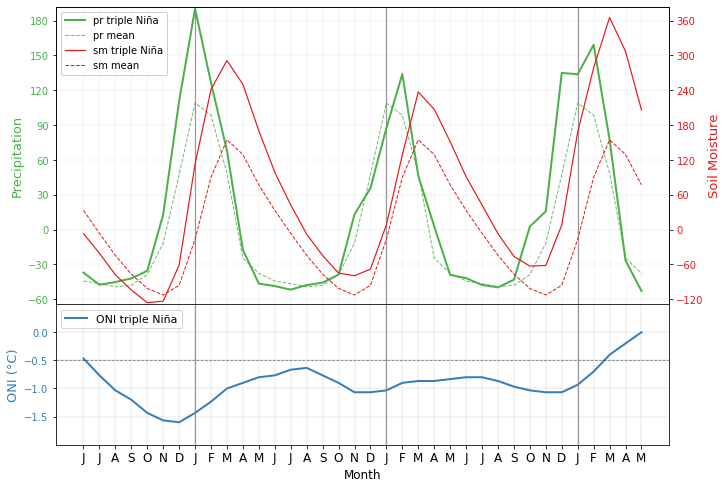

In [82]:
# ==========================================
# 6. PLOT (Grille à 2 panneaux)
# ==========================================
#pr_min, pr_max = -2.2, 6.2
#sm_min, sm_max = -44, 124
pr_min, pr_max = -64, 192
sm_min, sm_max = -128, 384

line_names = ['J','J','A','S','O','N','D','J','F','M','A','M'] * 3

fig = plt.figure(figsize=(11, 8.5))
# On divise en 2 panneaux: 1 grand pour l'hydro, 1 moyen pour ONI/IOD
gs = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1.2], hspace=0.1) 

# --- PANEL 1: HYDROLOGY (Main) ---
ax1 = fig.add_subplot(gs[0])
color_pr = '#4daf4a'
ax1.plot(prec_vector, label='pr triple Niña', color=color_pr, linewidth=2, zorder=5)
ax1.plot(prec_vector_MWCm, label='pr mean', color=color_pr, linestyle='--', linewidth=1, alpha=0.8)

ax1.set_ylabel('Precipitation', color=color_pr, fontsize=13)
ax1.tick_params(axis='y', labelcolor=color_pr)
ax1.set_ylim(pr_min, pr_max)
ax1.set_yticks([-60, -30, 0, 30, 60, 90, 120, 150, 180])
ax1.set_xticks(np.arange(36))
ax1.set_xticklabels([]) 
ax1.grid(True, axis='both', linewidth=0.3, alpha=0.5)

for tick in [7, 19, 31]:
    ax1.axvline(x=tick, color='gray', linewidth=1.2, alpha=0.8)

# TWIN AXIS : SOIL MOISTURE
ax2 = ax1.twinx()
color_sm = '#e41a1c'
ax2.plot(sm_vector, label='sm triple Niña', color=color_sm, linestyle='-', linewidth=1.2)
ax2.plot(sm_vector_MWCm, label='sm mean', linestyle='--', color=color_sm, linewidth=1)

ax2.set_ylabel('Soil Moisture', color=color_sm, fontsize=13)
ax2.tick_params(axis='y', labelcolor=color_sm)
ax2.set_ylim(sm_min, sm_max)
ax2.set_yticks([-120,-60, 0, 60, 120, 180, 240, 300, 360])

# Légende du panneau 1
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', ncol=1, fontsize=10, frameon=True, facecolor='white', framealpha=1)

# --- PANEL 2: OCEAN DRIVERS (ONI & IOD) ---
#ax3 = fig.add_subplot(gs[1], sharex=ax1)

pos = ax1.get_position()
ax3 = fig.add_axes([pos.x0, 0.164, pos.width, 0.23])

color_oni = '#377eb8'
ax3.plot(sst_3yr, label='ONI triple Niña', color=color_oni, linestyle='-', linewidth=2)

#color_iod = '#ff7f00'
#ax3.plot(iod_3yr, label='IOD (DMI) triple Niña', color=color_iod, linestyle='-', linewidth=2)

ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('ONI (°C)', color=color_oni, fontsize=13)
ax3.axhline(-0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Limites pour englober à la fois l'ONI et l'IOD
ax3.set_ylim(-2, 0.5)
ax3.set_yticks([-1.5, -1, -0.5,0])
ax3.grid(True, linewidth=0.3)
ax3.legend(loc='upper left', fontsize=11, ncol=2)

ax3.set_xticks(np.arange(36))
ax3.set_xticklabels(line_names, fontsize=12)
ax3.tick_params(axis='y', labelcolor=color_oni)

for tick in [7, 19, 31]:
    ax3.axvline(x=tick, color='gray', linewidth=1.2, alpha=0.8)

# Sauvegarde de l'image (ajuste le chemin de sauvegarde selon tes préférences NCI/Jupyter)
fig.savefig('/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/36mth_TLN_sm_pr_oni_0-6m.png', bbox_inches='tight', dpi=300)
plt.show()

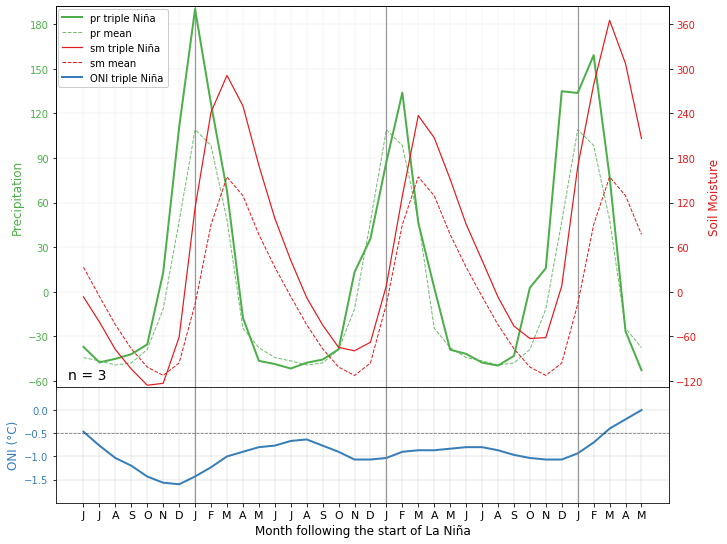

In [11]:
# --- Calculation of proportional limits ---
# Let's say we want to go from 6 to 8 for precipitation (+33%)
# Precipitation: range from -2 to 6.2 (Total span: 8.2)
pr_min, pr_max = -64, 192
sm_min, sm_max = -128, 384

fig, ax1 = plt.subplots(figsize=(11, 7))
line_names = ['J','J','A','S','O','N','D','J','F','M','A','M'] * 3

# --- 1. PRECIPITATION (Left Y-Axis) ---
color_pr = '#4daf4a'
ax1.plot(prec_vector, label='pr triple Niña', color=color_pr, linewidth=2, zorder=5)
ax1.plot(prec_vector_MWCm, label='pr mean', color=color_pr, linestyle='--', linewidth=1, alpha=0.8)

ax1.set_ylabel('Precipitation', color=color_pr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_pr)

# Updated Limits
ax1.set_ylim(pr_min, pr_max)
ax1.set_yticks([-60, -30, 0, 30, 60, 90, 120, 150, 180])

ax1.set_xticks(np.arange(36))
ax1.set_xticklabels([]) 
ax1.grid(True, axis='both', linewidth=0.3, alpha=0.5)

# Year separators
for tick in [7, 19, 31]:
    ax1.axvline(x=tick, color='gray', linewidth=1.2, alpha=0.8)

# --- 2. SOIL MOISTURE (Right Y-Axis) ---
ax2 = ax1.twinx()
color_sm = '#e41a1c'
ax2.plot(sm_vector, label='sm triple Niña', color=color_sm, linestyle='-', linewidth=1.2)
ax2.plot(sm_vector_MWCm, label='sm mean', linestyle='--', color=color_sm, linewidth=1)

ax2.set_ylabel('Soil Moisture', color=color_sm, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_sm)

# Updated Proportional Limits
ax2.set_ylim(sm_min, sm_max)
ax2.set_yticks([-120,-60, 0, 60, 120, 180, 240, 300, 360])

# --- 3. ONI INDEX (Bottom Panel) ---
pos = ax1.get_position()
# We slightly lower the bottom panel to give more "breathing room"
ax3 = fig.add_axes([pos.x0, -0.105, pos.width, 0.23])

color_oni = '#377eb8'
ax3.plot(sst_3yr, label='ONI triple Niña', color=color_oni, linestyle='-', linewidth=2)

ax3.set_xlabel('Month following the start of La Niña', fontsize=12)
ax3.set_ylabel('ONI (°C)', color=color_oni, fontsize=12)
ax3.tick_params(axis='y', labelcolor=color_oni)
ax3.set_ylim(-2, 0.5)
ax3.set_yticks([0.0, -0.5, -1.0, -1.5])

ax3.set_xticks(np.arange(36))
ax3.set_xticklabels(line_names, fontsize=11)
ax3.grid(True, linewidth=0.3)

for tick in [7, 19, 31]:
    ax3.axvline(x=tick, color='gray', linewidth=1.2, alpha=0.8)

ax3.axhline(-0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.text(0.02, 0.02, 'n = 3', transform=ax1.transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2), zorder=10)
# --- 4. LEGEND AND FINISHING ---

# 1. Collect handles and labels from all THREE axes
h1, l1 = ax1.get_legend_handles_labels() # Precipitation
h2, l2 = ax2.get_legend_handles_labels() # Soil Moisture
h3, l3 = ax3.get_legend_handles_labels() # ONI Index

# 2. Merge them all into one list
all_handles = h1 + h2 + h3
all_labels = l1 + l2 + l3

# 3. Create the unified legend
# I adjusted the bbox_to_anchor slightly so it doesn't overlap with the new 6.2 height
legend = fig.legend(all_handles, all_labels, loc='upper left', bbox_to_anchor=(0.122, 0.885), fontsize=10, frameon=True, facecolor='white', framealpha=1)

fig.savefig('/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/36mth_TLN_sm_pr_oni_0-6m.png', bbox_inches='tight', dpi=300)
plt.show()

In [16]:
# ==========================================
# CALCUL SAM — Méthode Marshall (2003) / NOAA
# SAM = anomalie normalisée (p40 - p65)
# Période de référence : 1981-2010
# ==========================================

# sam est déjà une pd.Series avec p40 - p65 en Pa (cellule 1)
# On la convertit en hPa d'abord
p40_hpa = p40 / 100.0
p65_hpa = p65 / 100.0

# ── Référence climatologique 1981-2010 ───────────────────────────────────────
ref_start, ref_end = '1981-01-01', '2010-12-31'

# Moyenne et écart-type mensuels sur la période de référence
p40_ref = p40_hpa.loc[ref_start:ref_end]
p65_ref = p65_hpa.loc[ref_start:ref_end]

# Groupby mois pour avoir la climatologie mensuelle
p40_clim_mean = p40_ref.groupby(p40_ref.index.month).mean()
p40_clim_std  = p40_ref.groupby(p40_ref.index.month).std()

p65_clim_mean = p65_ref.groupby(p65_ref.index.month).mean()
p65_clim_std  = p65_ref.groupby(p65_ref.index.month).std()

# ── Normalisation mensuelle sur toute la série ───────────────────────────────
def normalize_monthly(series, clim_mean, clim_std):
    """Soustrait la moyenne mensuelle et divise par l'écart-type mensuel."""
    norm = series.copy()
    for month in range(1, 13):
        idx = series.index.month == month
        norm[idx] = (series[idx] - clim_mean[month]) / clim_std[month]
    return norm

p40_norm = normalize_monthly(p40_hpa, p40_clim_mean, p40_clim_std)
p65_norm = normalize_monthly(p65_hpa, p65_clim_mean, p65_clim_std)

# ── SAM = différence des anomalies normalisées ────────────────────────────────
# Signe conventionnel : SAM+ = pression haute aux 40S, basse aux 65S
sam_index = p40_norm - p65_norm

# Conversion en xr.DataArray pour get_composite
sam_ts_raw = xr.DataArray.from_series(sam_index)

print(f"SAM recalculé ✓")
print(f"   Plage de valeurs : {sam_index.min():.2f} → {sam_index.max():.2f}")
print(f"   Moyenne sur 1981-2010 : {sam_index.loc[ref_start:ref_end].mean():.3f} (≈0 attendu)")
print(f"   Std sur 1981-2010     : {sam_index.loc[ref_start:ref_end].std():.3f}  (≈1.4 attendu)")

SAM recalculé ✓
   Plage de valeurs : -8.07 → 4.86
   Moyenne sur 1981-2010 : 0.000 (≈0 attendu)
   Std sur 1981-2010     : 1.801  (≈1.4 attendu)


sam_3yr plage : -1.29 → 2.10
SAM plage : -1.29 → 2.10


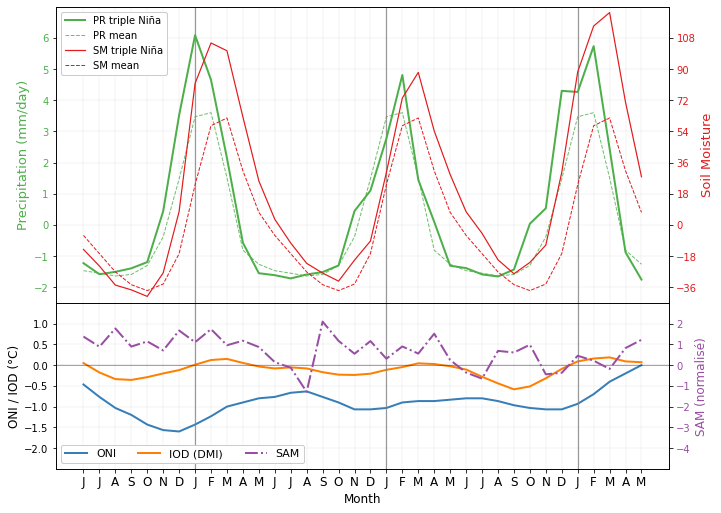

In [33]:
# ── Après le calcul de sam_ts_raw, AVANT le plot ─────────────────────────────

# Conversion avec la bonne dimension
sam_ts_raw = xr.DataArray.from_series(sam_index).rename({'index': 'time'})

# Detrending
sam_ts = apply_detrend(sam_ts_raw)

# Composite
sam_3yr = get_composite(sam_ts, triple_la_nina)

print(f"sam_3yr plage : {float(sam_3yr.min()):.2f} → {float(sam_3yr.max()):.2f}")
# ==========================================
# CELLULE PLOT — 2 panneaux (SAM intégré avec ONI/IOD)
# ==========================================

# Vérification que sam_ts_raw est bien le SAM normalisé
print(f"SAM plage : {float(sam_3yr.min()):.2f} → {float(sam_3yr.max()):.2f}")

pr_min, pr_max = -2.5, 7
sm_min, sm_max = -45, 126
line_names = ['J','J','A','S','O','N','D','J','F','M','A','M'] * 3

fig = plt.figure(figsize=(11, 8.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1.4], hspace=0)

# ── PANEL 1 : HYDROLOGY ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
color_pr = '#4daf4a'
ax1.plot(prec_vector,      label='PR triple Niña', color=color_pr, linewidth=2, zorder=5)
ax1.plot(prec_vector_MWCm, label='PR mean',        color=color_pr, linestyle='--', linewidth=1, alpha=0.8)
ax1.set_ylabel('Precipitation (mm/day)', color=color_pr, fontsize=13)
ax1.tick_params(axis='y', labelcolor=color_pr)
ax1.set_ylim(pr_min, pr_max)
ax1.set_yticks([-2, -1, 0, 1, 2, 3, 4, 5, 6])
ax1.set_xticks(np.arange(36))
ax1.set_xticklabels([])
ax1.grid(True, axis='both', linewidth=0.3, alpha=0.5)
for tick in [7, 19, 31]:
    ax1.axvline(x=tick, color='gray', linewidth=1.2, alpha=0.8)

ax2 = ax1.twinx()
color_sm = '#e41a1c'
ax2.plot(sm_vector,      label='SM triple Niña', color=color_sm, linestyle='-',  linewidth=1.2)
ax2.plot(sm_vector_MWCm, label='SM mean',        color=color_sm, linestyle='--', linewidth=1)
ax2.set_ylabel('Soil Moisture', color=color_sm, fontsize=13)
ax2.tick_params(axis='y', labelcolor=color_sm)
ax2.set_ylim(sm_min, sm_max)
ax2.set_yticks([-36,-18, 0, 18, 36, 54, 72, 90, 108])

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', fontsize=10, frameon=True, facecolor='white', framealpha=1)

# ── PANEL 2 : ONI / IOD (gauche) + SAM (droite) ──────────────────────────────
ax3 = fig.add_subplot(gs[1])
ax3b = ax3.twinx()

color_oni = '#377eb8'
color_iod = '#ff7f00'
color_sam = '#984ea3'

# ONI et IOD — axe gauche
ax3.plot(sst_3yr, label='ONI',       color=color_oni, linewidth=2)
ax3.plot(iod_3yr, label='IOD (DMI)', color=color_iod, linewidth=2)
ax3.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax3.set_ylabel('ONI / IOD (°C)', fontsize=12)
ax3.set_ylim(-2.5, 1.5)
ax3.set_yticks([-2, -1.5, -1, -0.5, 0, 0.5, 1])
ax3.tick_params(axis='y')

# SAM normalisé — axe droit
ax3b.plot(sam_3yr, label='SAM', color=color_sam, linewidth=2, linestyle='-.')
ax3b.axhline(0, color=color_sam, linewidth=0.4, alpha=0.4)
ax3b.set_ylabel('SAM (normalisé)', color=color_sam, fontsize=12)
ax3b.tick_params(axis='y', labelcolor=color_sam)
ax3b.set_ylim(-5, 3)
ax3b.set_yticks([-4,-3, -2, -1, 0, 1, 2])

ax3.set_xticks(np.arange(36))
ax3.set_xticklabels(line_names, fontsize=12)
ax3.set_xlabel('Month', fontsize=12)
ax3.grid(True, linewidth=0.3, alpha=0.5)
for tick in [7, 19, 31]:
    ax3.axvline(x=tick, color='gray', linewidth=1.2, alpha=0.8)

# Légende combinée ONI + IOD + SAM
h1, l1 = ax3.get_legend_handles_labels()
h2, l2 = ax3b.get_legend_handles_labels()
ax3.legend(h1+h2, l1+l2, loc='lower left', fontsize=11, ncol=3,
           frameon=True, facecolor='white', framealpha=1)

#fig.savefig('/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/36mth_TLN_sm_pr_oni_iod_sam.png',
#            bbox_inches='tight', dpi=300)
plt.show()

## Single Tiple La Nina analysis

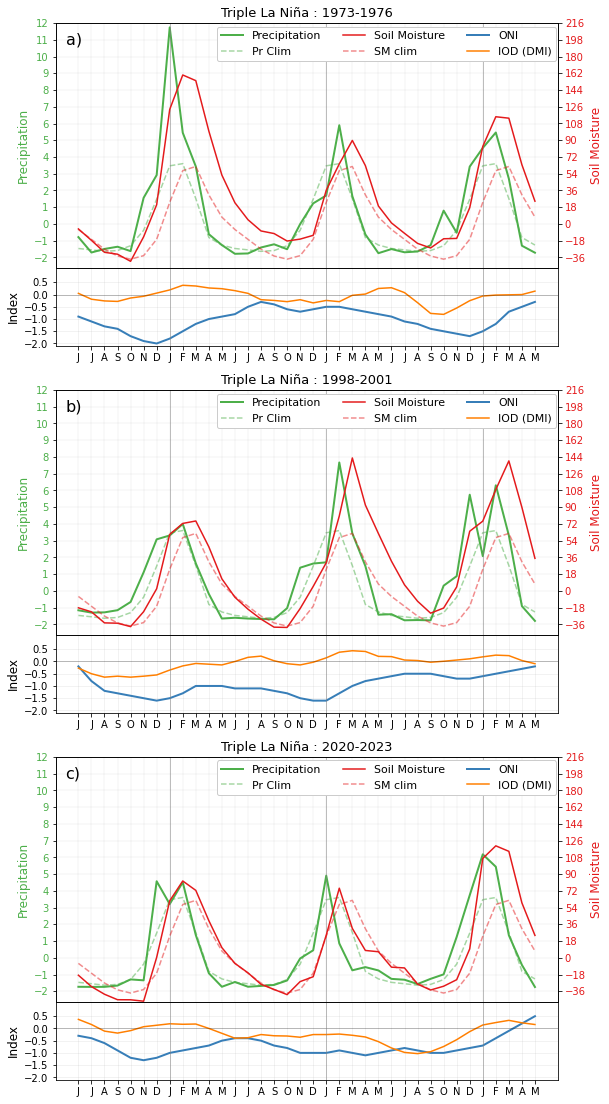

In [41]:
subplot_annots = ['a)', 'b)', 'c)']

fig, axes = plt.subplots(3, 1, figsize=(9, 18))
# J'augmente légèrement le hspace à 0.4 pour que les mois de (a) ne touchent pas le titre de (b)
plt.subplots_adjust(hspace=0.5) 

color_pr, color_sm = '#4daf4a', '#e41a1c'
color_oni, color_iod = '#377eb8', '#ff7f00'
line_names = ['J','J','A','S','O','N','D','J','F','M','A','M'] * 3

for i, ax in enumerate(axes):
    # --- 1. ANNOTATIONS ---
    ax.text(0.02, 0.96, subplot_annots[i], transform=ax.transAxes, 
            fontsize=16, va='top', ha='left')

    # --- 2. AXE HYDRO ---
    ln1 = ax.plot(all_prec[i], color=color_pr, linewidth=2, label='Precipitation')[0]
    ln2 = ax.plot(prec_clim_36, color=color_pr, linestyle='--', alpha=0.5, label='Pr Clim')[0]
    
    ax.set_xticks(np.arange(36))
    ax.set_xticklabels([]) 
        
    ax.set_ylabel('Precipitation', color=color_pr, fontsize=12)
    ax.tick_params(axis='y', labelcolor=color_pr)
    ax.set_ylim(-2.61, 12)
    ax.set_yticks([-2, -1, 0, 1, 2, 3, 4, 5, 6,7,8,9,10,11,12])
    ax.set_title(f"Triple La Niña : {event_labels[i]}", loc='center', fontsize=13)
    ax.grid(True, axis='both', linewidth=0.3, alpha=0.5)

    # --- 3. AXE SOIL MOISTURE ---
    ax2 = ax.twinx()
    ln3 = ax2.plot(all_sm[i], color=color_sm, linewidth=1.5, label='Soil Moisture')[0]
    ln4 = ax2.plot(sm_clim_36, color=color_sm, linestyle='--', alpha=0.5, label='SM clim')[0]
    ax2.set_ylabel('Soil Moisture', color=color_sm, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_sm)
    ax2.set_ylim(-47, 216)
    ax2.set_yticks([-36, -18, 0,  18, 36, 54, 72, 90, 108,126, 144,162, 180, 198, 216])

    # --- 4. AXE OCEAN (MODIFIÉ : PLUS DE SHAREX) ---
    # On enlève sharex pour TOUS les index i
    ax3 = ax.inset_axes([0, -0.32, 1, 0.32]) 
    ln5 = ax3.plot(all_oni[i], color=color_oni, label='ONI', linewidth=2)[0]
    ln6 = ax3.plot(all_iod[i], color=color_iod, label='IOD (DMI)', linestyle='-', linewidth=1.5)[0]
    ax3.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    ax3.set_ylim(-2.1, 1.1)
    ax3.set_yticks([-2, -1.5, -1, -0.5, 0, 0.5])
    ax3.set_ylabel('Index', fontsize=12)
    ax3.grid(True, alpha=0.2)
    
    # --- 5. LÉGENDES ---
    lines = [ln1, ln2, ln3, ln4, ln5, ln6]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right', fontsize=11, ncol=3, 
              framealpha=1, bbox_to_anchor=(1.008, 1.008))

    # --- 6. AFFICHAGE DES MOIS (PARTOUT) ---
    ax3.set_xticks(np.arange(36))
    ax3.set_xticklabels(line_names, fontsize=10) # On applique à chaque itération

    # Quadrillage vertical
    for tick in [7, 19, 31]:
        ax.axvline(x=tick, color='gray', linewidth=1, alpha=0.5)
        ax3.axvline(x=tick, color='gray', linewidth=1, alpha=0.5)

fig.savefig('/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/Single_events_3x1_36mth_TLN_sm_pr_oni_iod.png', dpi=300, bbox_inches='tight')
plt.show()

In [88]:
import pandas as pd

# 1. Définition des dimensions
# JJA correspond aux mois 0,1,2 du vecteur (qui commence en Juin)
seasons = ['JJA', 'SON', 'DJF', 'MAM']
variables = ['ONI (°C)', 'Precipitation anomaly (mm/month)', 'Soil Moisture anomaly (mm)']

# 2. Création du MultiIndex pour les colonnes
columns = pd.MultiIndex.from_product([variables, ['Year 1', 'Year 2', 'Year 3']],
                                     names=['Variable', 'Year'])

# 3. Calcul et remplissage des données
data_rows = []
for s_idx, s_name in enumerate(seasons):
    row = []
    for var_name in variables:
        for yr in range(3):
            # Mapping temporel : 
            # Comme ton vecteur commence en Juin (JJA), l'index 0-2 = JJA, 3-5 = SON, etc.
            start = (yr * 12) + (s_idx * 3)
            end = start + 3
            if var_name == 'ONI (°C)':
                # On extrait la portion, on calcule la moyenne
                data_slice = sst_3yr[start:end].mean()
                # On vérifie si on doit faire .compute() ou si c'est déjà du numpy
                val = data_slice.compute().item() if hasattr(data_slice, 'compute') else data_slice.item()
                
            elif var_name == 'Precipitation anomaly (mm/month)':
                # On fait la même chose pour la pluie et sa clim
                p_slice = prec_vector[start:end].mean()
                c_slice = prec_clim_36[start:end].mean()
                
                p_val = p_slice.compute().item() if hasattr(p_slice, 'compute') else p_slice.item()
                c_val = c_slice.compute().item() if hasattr(c_slice, 'compute') else c_slice.item()
                val = p_val - c_val
                
            else: # Soil Moisture anomaly (mm)
                # Idem pour la SM
                s_slice = sm_vector[start:end].mean()
                sc_slice = sm_clim_36[start:end].mean()
                
                s_val = s_slice.compute().item() if hasattr(s_slice, 'compute') else s_slice.item()
                sc_val = sc_slice.compute().item() if hasattr(sc_slice, 'compute') else sc_slice.item()
                val = s_val - sc_val
            row.append(val)
    data_rows.append(row)

# 4. Création du DataFrame final
df_final = pd.DataFrame(data_rows, index=seasons, columns=columns)

# 5. Application du style
styled_table = df_final.style.format(precision=2)\
    .set_properties(**{
        'text-align': 'center',
        'padding': '12px',
        'border': '1px solid #ddd',
        'font-family': 'Arial, sans-serif'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', 'white'), 
                                     ('color', '#2c3e50'), 
                                     ('font-weight', 'bold'),
                                     ('text-align', 'center'),
                                     ('border', '1px solid lightgrey')]},
        {'selector': 'th.row_heading', 'props': [('background-color', '#ecf0f1'), 
                                                 ('color', '#2c3e50')]}
    ])\
    .set_properties(subset=['ONI (°C)'], **{'background-color': '#f0f7ff'})\
    .set_properties(subset=['Precipitation anomaly (mm/month)'], **{'background-color': '#f2fff2'})\
    .set_properties(subset=['Soil Moisture anomaly (mm)'], **{'background-color': '#fff5f5'})

# Affichage
display(styled_table)